In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

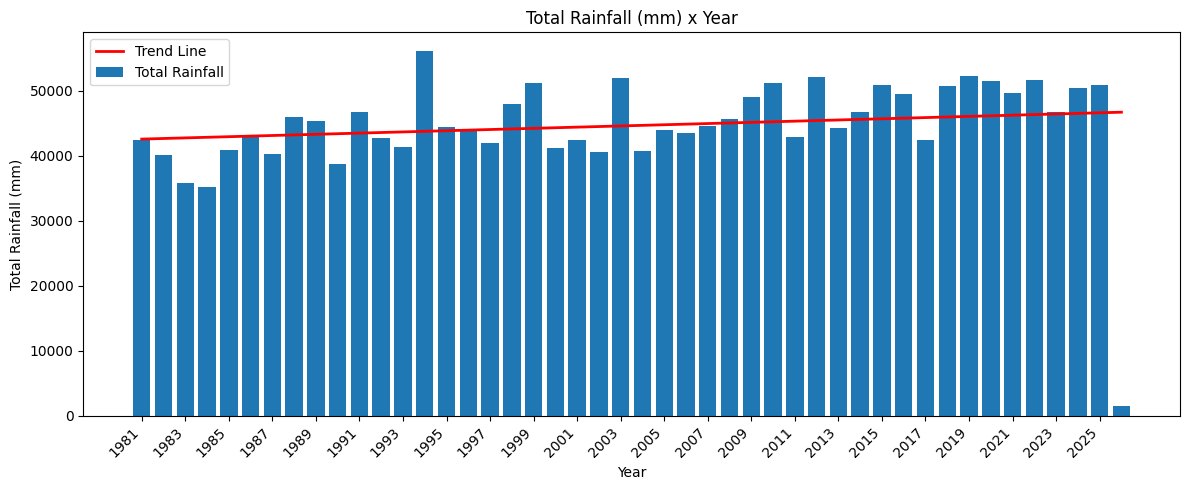

In [16]:
df = pd.read_csv('Data/bfa-rainfall-subnat-full.csv')
df['time'] = pd.to_datetime(df['date'])
df = df.sort_values('time')
yearly_total = df.groupby(df['time'].dt.year)['rfh'].sum()

plt.figure(figsize=(12, 5))
plt.bar(yearly_total.index.astype(str), yearly_total, label='Total Rainfall')

# Calculate and plot trend line
z = np.polyfit(yearly_total.index, yearly_total.values, 1)
p = np.poly1d(z)
plt.plot(yearly_total.index.astype(str), p(yearly_total.index), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Total Rainfall (mm) x Year')
plt.xticks(yearly_total.index[::2].astype(str), rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

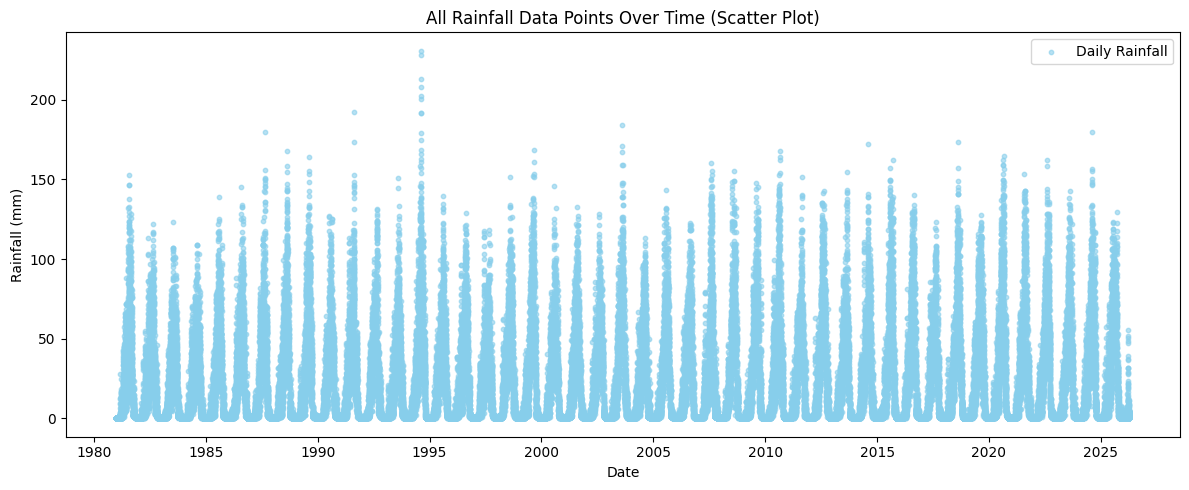

In [20]:
# Plot every rainfall datapoint as a scatter plot (not aggregated by year)
plt.figure(figsize=(12, 5))
plt.scatter(df['time'], df['rfh'], s=10, alpha=0.6, color='skyblue', label='Daily Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('All Rainfall Data Points Over Time (Scatter Plot)')
plt.legend()
plt.tight_layout()
plt.show()

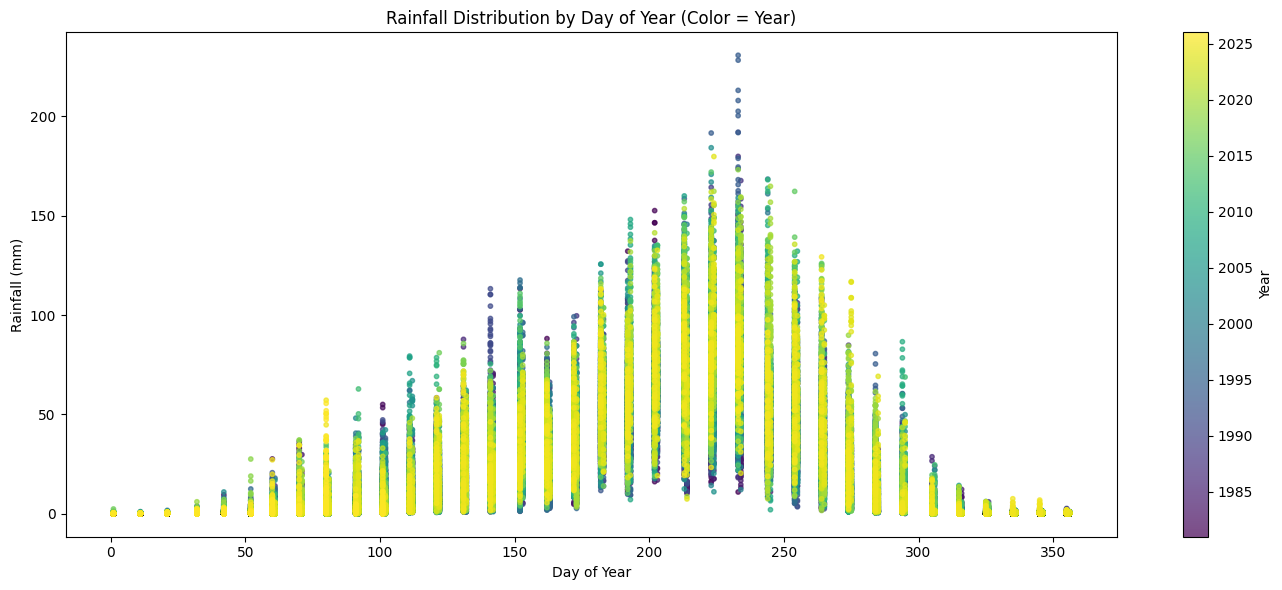

In [21]:
# Plot rainfall by day-of-year to visualize intra-annual variability over time
import matplotlib.dates as mdates

df['year'] = df['time'].dt.year
df['dayofyear'] = df['time'].dt.dayofyear

plt.figure(figsize=(14, 6))
scatter = plt.scatter(df['dayofyear'], df['rfh'], c=df['year'], cmap='viridis', s=10, alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Year')
plt.xlabel('Day of Year')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall Distribution by Day of Year (Color = Year)')
plt.tight_layout()
plt.show()

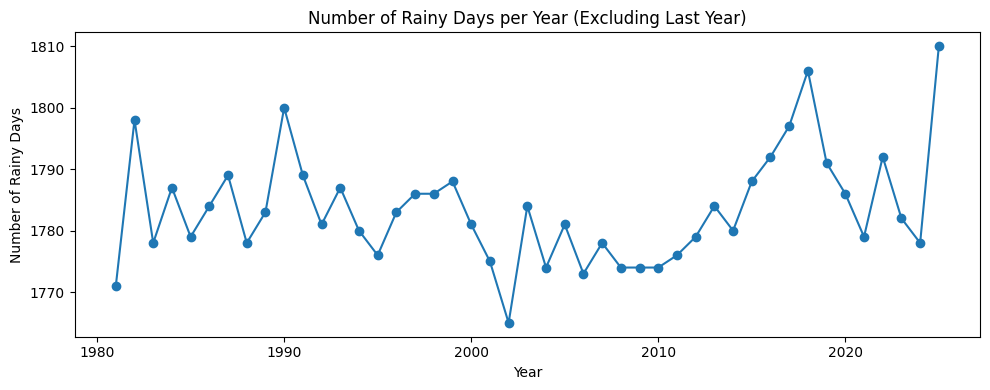

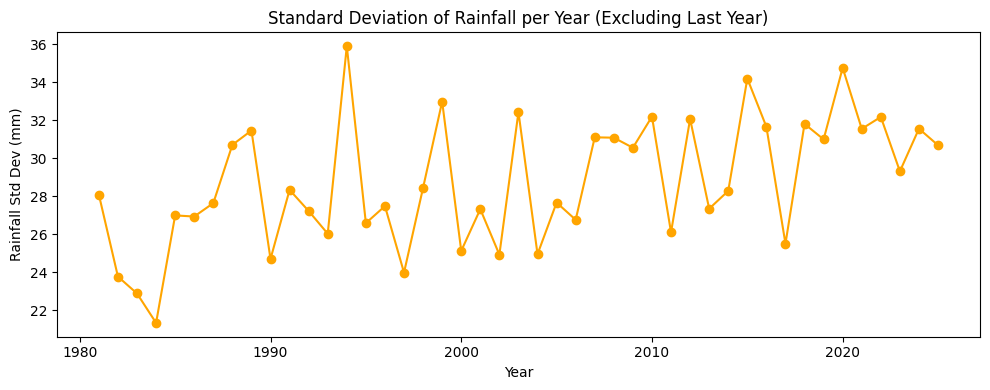

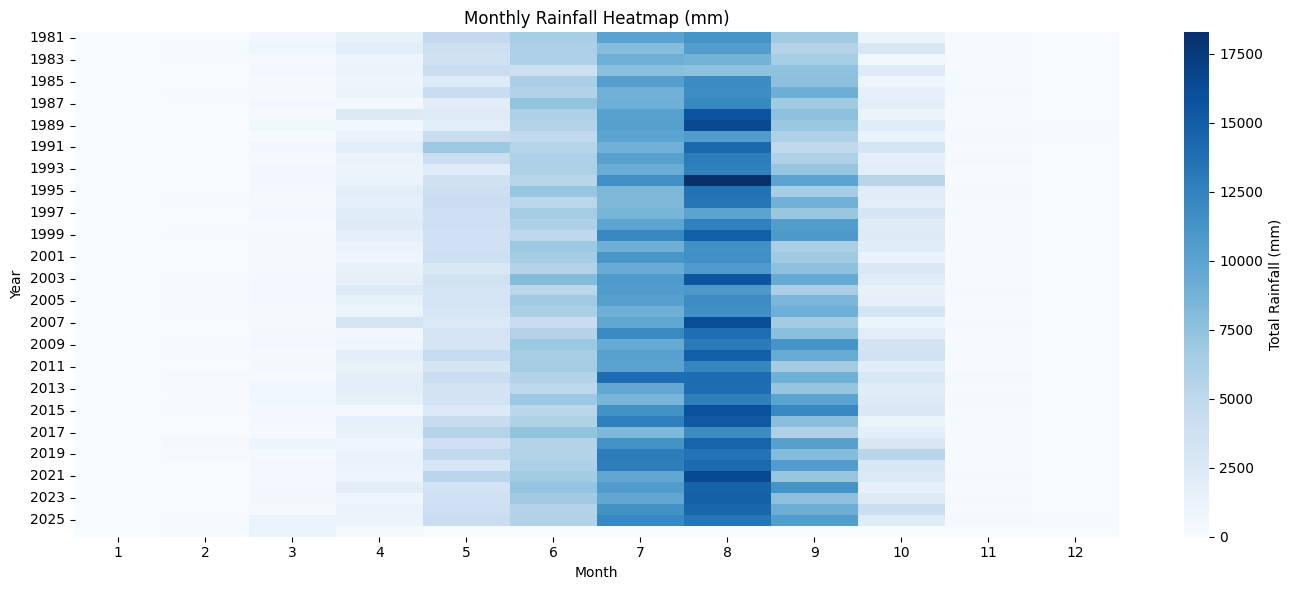

In [24]:
# 1. Number of rainy days per year (rainfall > 0), excluding last year
rainy_days_per_year = df[df['rfh'] > 0].groupby(df['year']).size()
rainy_days_per_year = rainy_days_per_year.iloc[:-1]  # Remove last data point
plt.figure(figsize=(10, 4))
plt.plot(rainy_days_per_year.index, rainy_days_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Rainy Days')
plt.title('Number of Rainy Days per Year (Excluding Last Year)')
plt.tight_layout()
plt.show()

# 2. Standard deviation of rainfall per year (variability), excluding last year
std_rainfall_per_year = df.groupby(df['year'])['rfh'].std()
std_rainfall_per_year = std_rainfall_per_year.iloc[:-1]  # Remove last data point
plt.figure(figsize=(10, 4))
plt.plot(std_rainfall_per_year.index, std_rainfall_per_year.values, marker='o', color='orange')
plt.xlabel('Year')
plt.ylabel('Rainfall Std Dev (mm)')
plt.title('Standard Deviation of Rainfall per Year (Excluding Last Year)')
plt.tight_layout()
plt.show()

# 3. Heatmap of rainfall by month and year (unchanged)
monthly_rain = df.copy()
monthly_rain['month'] = monthly_rain['time'].dt.month
monthly_sum = monthly_rain.groupby(['year', 'month'])['rfh'].sum().unstack(fill_value=0)
import seaborn as sns
plt.figure(figsize=(14, 6))
sns.heatmap(monthly_sum, cmap='Blues', cbar_kws={'label': 'Total Rainfall (mm)'})
plt.xlabel('Month')
plt.ylabel('Year')
plt.title('Monthly Rainfall Heatmap (mm)')
plt.tight_layout()
plt.show()

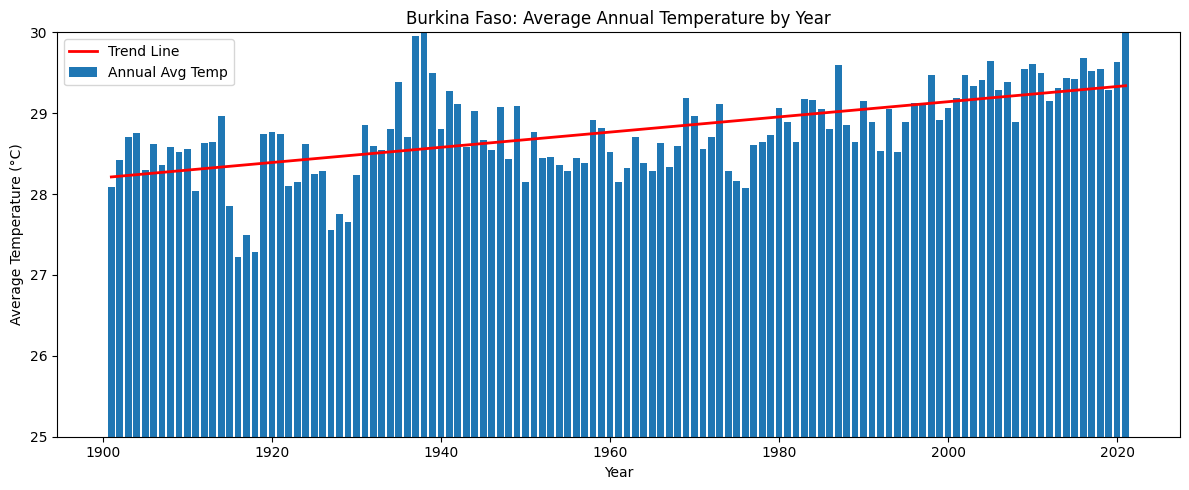

In [14]:
df = pd.read_csv('Data/burkina-faso-tas_timeseries_annual_cru_1901-2021_bfa.csv', skiprows=1)
# The first column is the year, the second is the national average
df.columns.values[0] = 'Year'
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])

plt.figure(figsize=(12,5))
plt.bar(df['Year'], df['Burkina Faso'], label='Annual Avg Temp')

# Calculate and plot trend line
z = np.polyfit(df['Year'], df['Burkina Faso'], 1)
p = np.poly1d(z)
plt.plot(df['Year'], p(df['Year']), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.title('Burkina Faso: Average Annual Temperature by Year')
plt.ylim(25, 30)
plt.legend()
plt.tight_layout()
plt.show()